Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')  # To import from src

from src.data.load_data import load_cmapss_data, add_rul_column

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports successful")



✓ Imports successful


Load Data

In [2]:
# Load FD001 dataset
train_df, test_df, rul_df = load_cmapss_data('FD001', data_dir='../data/raw')

# Add RUL to training data
train_df = add_rul_column(train_df)

print(f"Training engines: {train_df['engine_id'].nunique()}")
print(f"Test engines: {test_df['engine_id'].nunique()}")
print(f"Total training cycles: {len(train_df)}")
print(f"Total test cycles: {len(test_df)}")

✓ Loaded FD001
  Training data: (20631, 26)
  Test data: (13096, 26)
  RUL labels: (100, 1)
Training engines: 100
Test engines: 100
Total training cycles: 20631
Total test cycles: 13096


 Understand One Engine

Engine 1 ran for 192 cycles
RUL at start: 191
RUL at end: 0


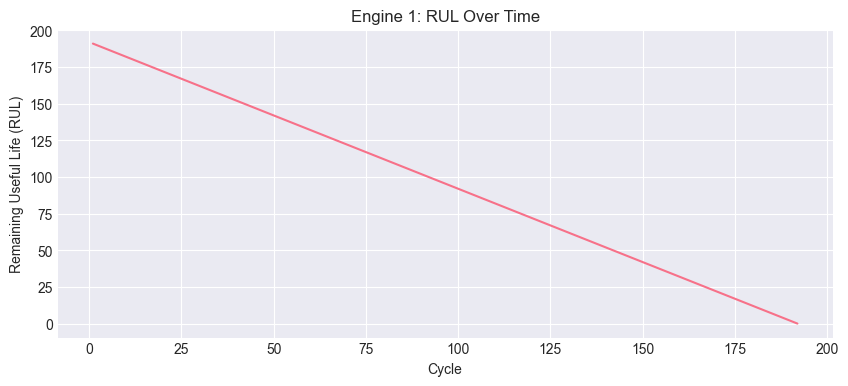

In [3]:
# Look at engine 1
engine_1 = train_df[train_df['engine_id'] == 1]

print(f"Engine 1 ran for {engine_1['cycle'].max()} cycles")
print(f"RUL at start: {engine_1['RUL'].iloc[0]}")
print(f"RUL at end: {engine_1['RUL'].iloc[-1]}")

# Plot RUL over time for engine 1
plt.figure(figsize=(10, 4))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (RUL)')
plt.title('Engine 1: RUL Over Time')
plt.grid(True)
plt.show()

Visualize Multiple Engines

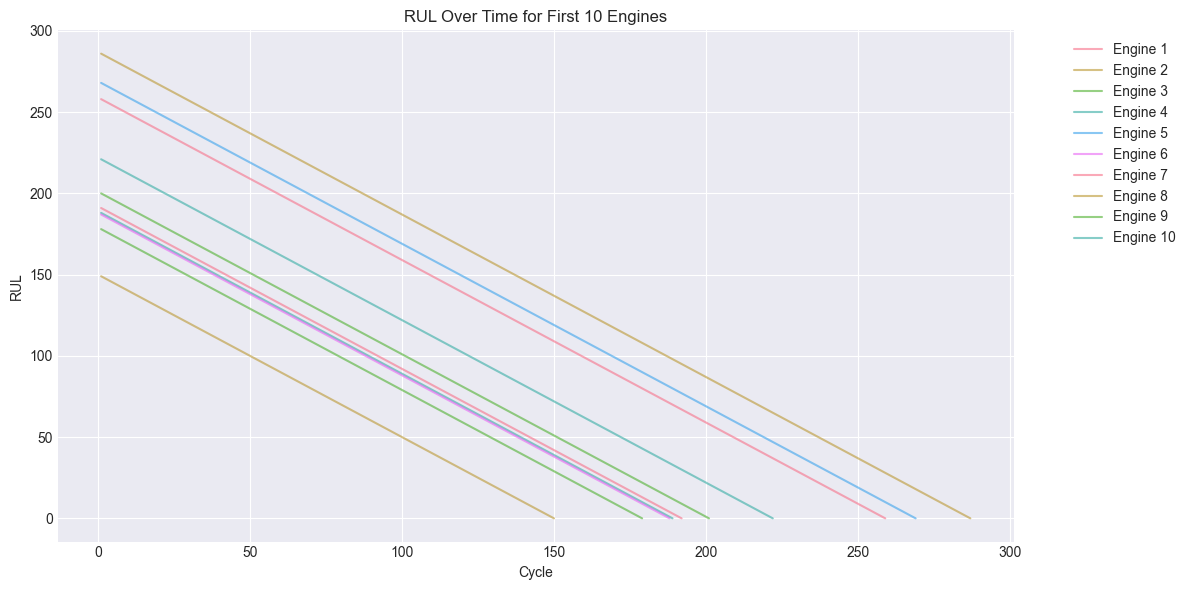

In [4]:
# Plot RUL for first 10 engines
plt.figure(figsize=(12, 6))

for engine_id in range(1, 11):
    engine_data = train_df[train_df['engine_id'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['RUL'], alpha=0.6, label=f'Engine {engine_id}')

plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('RUL Over Time for First 10 Engines')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

 Engine Lifetimes Distribution

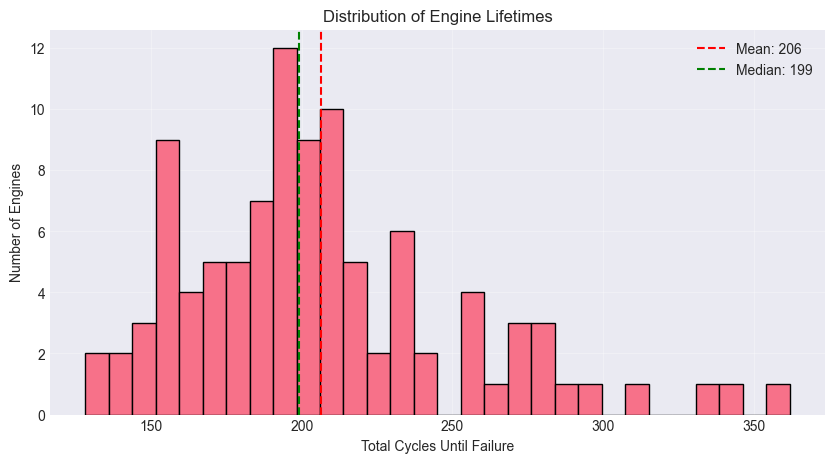

Min lifetime: 128 cycles
Max lifetime: 362 cycles
Mean lifetime: 206.3 cycles
Median lifetime: 199.0 cycles


In [5]:
# How long does each engine run?
engine_lifetimes = train_df.groupby('engine_id')['cycle'].max()

plt.figure(figsize=(10, 5))
plt.hist(engine_lifetimes, bins=30, edgecolor='black')
plt.xlabel('Total Cycles Until Failure')
plt.ylabel('Number of Engines')
plt.title('Distribution of Engine Lifetimes')
plt.axvline(engine_lifetimes.mean(), color='red', linestyle='--', label=f'Mean: {engine_lifetimes.mean():.0f}')
plt.axvline(engine_lifetimes.median(), color='green', linestyle='--', label=f'Median: {engine_lifetimes.median():.0f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Min lifetime: {engine_lifetimes.min()} cycles")
print(f"Max lifetime: {engine_lifetimes.max()} cycles")
print(f"Mean lifetime: {engine_lifetimes.mean():.1f} cycles")
print(f"Median lifetime: {engine_lifetimes.median():.1f} cycles")

 Sensor Overview

In [6]:
# Get sensor columns
sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]

print(f"Number of sensors: {len(sensor_cols)}")
print(f"Sensor columns: {sensor_cols}")

# Check which sensors are constant (variance near zero)
sensor_variance = train_df[sensor_cols].var()

print("\nSensor Variance:")
print(sensor_variance.sort_values())

# Identify constant sensors (variance < 0.01)
constant_sensors = sensor_variance[sensor_variance < 0.01].index.tolist()
print(f"\n⚠ Constant sensors (will be removed): {constant_sensors}")

Number of sensors: 21
Sensor columns: ['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

Sensor Variance:
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.926023e-34
sensor_5     3.155597e-30
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64

⚠ Constant sensors (will be removed): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_8', 'sensor_10', 'sensor_13', 'sen

 Visualize Sensor Trends

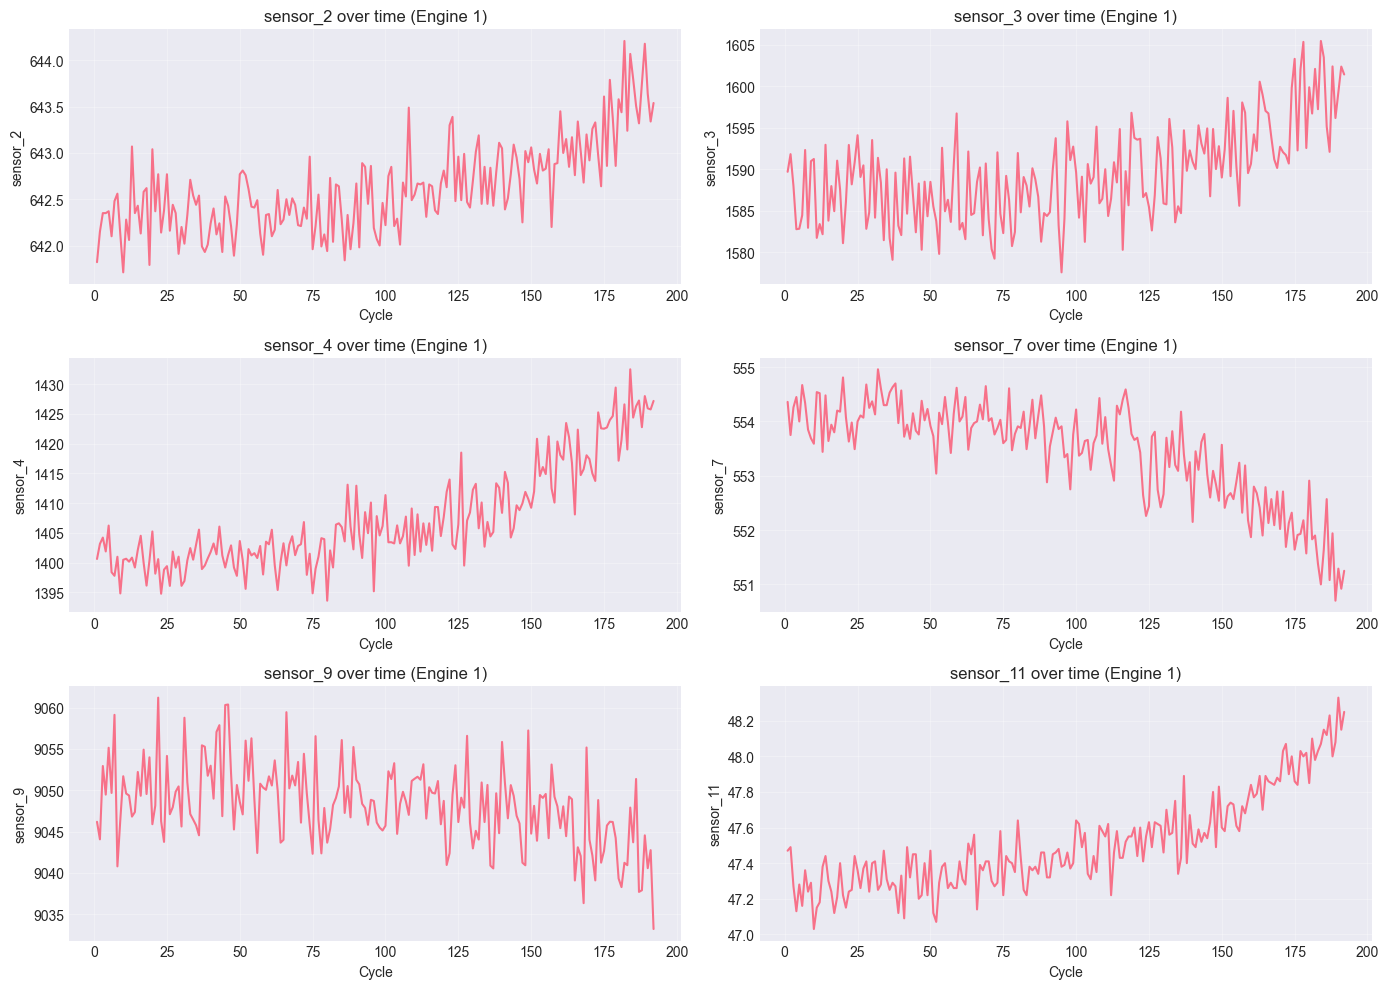

In [7]:
# Pick one engine and visualize sensors over its lifetime
engine_id = 1
engine_data = train_df[train_df['engine_id'] == engine_id]

# Remove constant sensors
useful_sensors = [s for s in sensor_cols if s not in constant_sensors]

# Plot first 6 useful sensors
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(useful_sensors[:6]):
    axes[i].plot(engine_data['cycle'], engine_data[sensor])
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel(sensor)
    axes[i].set_title(f'{sensor} over time (Engine {engine_id})')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Summary

In [8]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Training engines: {train_df['engine_id'].nunique()}")
print(f"Test engines: {test_df['engine_id'].nunique()}")
print(f"Total sensors: {len(sensor_cols)}")
print(f"Useful sensors: {len(useful_sensors)}")
print(f"Constant sensors to remove: {len(constant_sensors)}")
print(f"Average engine lifetime: {engine_lifetimes.mean():.1f} cycles")
print(f"Max RUL in training: {train_df['RUL'].max()}")
print("="*60)

DATASET SUMMARY
Training engines: 100
Test engines: 100
Total sensors: 21
Useful sensors: 11
Constant sensors to remove: 10
Average engine lifetime: 206.3 cycles
Max RUL in training: 361
